### Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from services.api import *
from services.functions import *

# Dummy_json_data Analysis and Visualization

### Carts Dataframe Cleaning

In [2]:
raw_carts_df=api_get_data(dataset="carts")

In [3]:
carts_df = convert_to_pandas_df(raw_carts_df)

In [4]:
len(carts_df)

208

In [5]:
carts_df.rename(columns={
    "id": "cart_id",
    "userId": "user_id"
}, inplace=True)
carts_df

,cart_id,products,total,discountedTotal,user_id,totalProducts,totalQuantity
0,1,"[{'id': 162, 'title': 'Blue Frock', 'price': 2...",13037.88,11510.81,1,4,12
1,2,"[{'id': 86, 'title': 'Man Short Sleeve Shirt',...",139.93,125.70,2,2,7
2,3,"[{'id': 24, 'title': 'Fish Steak', 'price': 14...",1794.85,1625.77,3,6,15
3,4,"[{'id': 92, 'title': 'Sports Sneakers Off Whit...",689.93,636.81,4,2,7
4,5,"[{'id': 161, 'title': 'Samsung Galaxy Tab Whit...",1467.88,1205.80,5,3,12
...,...,...,...,...,...,...,...
203,204,"[{'id': 141, 'title': 'Basketball Rim', 'price...",25591.84,23182.99,204,6,16
204,205,"[{'id': 62, 'title': 'Ice Cube Tray', 'price':...",16011.94,14075.86,205,2,6
205,206,"[{'id': 141, 'title': 'Basketball Rim', 'price...",229.92,213.26,206,3,8
206,207,"[{'id': 137, 'title': 'American Football', 'pr...",22719.79,20090.11,207,6,21


In [6]:
cart_items_df = convert_to_pandas_df(
    raw_carts_df,
    record_path="products",
    meta=["id", "userId"],
    df_name="cart_"
)

In [7]:
cart_items_df.rename(
    columns={
        "id": "product_id",
        "cart_userId": "user_id"
    },
    inplace=True
)
cart_items_df.head(10)

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id
0,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1
1,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1
2,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1
3,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1
4,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2
5,104,Apple iPhone Charger,19.99,2,39.98,18.52,32.58,https://cdn.dummyjson.com/product-images/mobil...,2,2
6,24,Fish Steak,14.99,1,14.99,4.23,14.36,https://cdn.dummyjson.com/product-images/groce...,3,3
7,123,iPhone 13 Pro,1099.99,1,1099.99,9.37,996.92,https://cdn.dummyjson.com/product-images/smart...,3,3
8,129,Realme X,299.99,1,299.99,6.95,279.14,https://cdn.dummyjson.com/product-images/smart...,3,3
9,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,3,3


In [8]:
cart_items_df[cart_items_df.duplicated()]

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id
25,56,Electric Stove,49.99,1,49.99,14.04,42.97,https://cdn.dummyjson.com/product-images/kitch...,7,7
143,110,Selfie Lamp with iPhone,14.99,2,29.98,19.40,24.16,https://cdn.dummyjson.com/product-images/mobil...,38,38


In [9]:
cart_items_df=remove_duplicates(cart_items_df)

2 duplicates have been found and removed from the dataframe.


In [10]:
cart_items_df=cast_columns(cart_items_df,
                       columns_dict={
                           "cart_id":"int",
                           "user_id":"int"
                       }
                       )

In [11]:
cart_items_df.head(10)

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id
0,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1
1,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1
2,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1
3,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1
4,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2
5,104,Apple iPhone Charger,19.99,2,39.98,18.52,32.58,https://cdn.dummyjson.com/product-images/mobil...,2,2
6,24,Fish Steak,14.99,1,14.99,4.23,14.36,https://cdn.dummyjson.com/product-images/groce...,3,3
7,123,iPhone 13 Pro,1099.99,1,1099.99,9.37,996.92,https://cdn.dummyjson.com/product-images/smart...,3,3
8,129,Realme X,299.99,1,299.99,6.95,279.14,https://cdn.dummyjson.com/product-images/smart...,3,3
9,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,3,3


In [12]:
cart_items_df,cart_inc_df=inconsistent_values(cart_items_df)

The product_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The price contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The quantity contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The total contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The discountPercentage contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The discountedTotal contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The cart_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The user_id contains 0 incosi

### Products Dataframe Cleansing

In [13]:
raw_pr_df=api_get_data(dataset="products")

In [14]:
products_df=convert_to_pandas_df(raw_pr_df,"products")

In [15]:
pd.set_option("display.max_columns", None)

In [16]:
products_df.rename(
    columns={"id":"product_id"},
    inplace=True
)
products_df=products_df[
    ["product_id","title","category","price","discountPercentage","rating","stock","brand","shippingInformation","availabilityStatus","returnPolicy","minimumOrderQuantity"]
    ]


In [17]:
products_df=remove_duplicates(products_df)

0 duplicates have been found and removed from the dataframe.


In [18]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            194 non-null    int64  
 1   title                 194 non-null    str    
 2   category              194 non-null    str    
 3   price                 194 non-null    float64
 4   discountPercentage    194 non-null    float64
 5   rating                194 non-null    float64
 6   stock                 194 non-null    int64  
 7   brand                 102 non-null    str    
 8   shippingInformation   194 non-null    str    
 9   availabilityStatus    194 non-null    str    
 10  returnPolicy          194 non-null    str    
 11  minimumOrderQuantity  194 non-null    int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 18.3 KB


In [19]:
products_df, inc_products_df=inconsistent_values(products_df)

The product_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The price contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The discountPercentage contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The rating contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The stock contains 4 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The minimumOrderQuantity contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df


In [49]:
# Out of stock products
inc_products_df

,product_id,title,category,price,discountPercentage,rating,stock,brand,shippingInformation,availabilityStatus,returnPolicy,minimumOrderQuantity
116,117,Sportbike Motorcycle,motorcycle,7499.99,11.58,3.94,0,SpeedMaster,Ships in 2 weeks,Out of Stock,30 days return policy,1
131,132,Samsung Galaxy S8,smartphones,499.99,19.45,4.40,0,Samsung,Ships in 1 week,Out of Stock,No return policy,4
152,153,Volleyball,sports-accessories,11.99,12.25,3.84,0,NaN,Ships in 1 week,Out of Stock,90 days return policy,44
192,193,Watch Gold for Women,womens-watches,799.99,18.34,4.24,0,Fashion Gold,Ships in 1-2 business days,Out of Stock,60 days return policy,1


### User Dataframe Cleansing

In [20]:
raw_user=api_get_data(dataset="users")

In [21]:
user_df=convert_to_pandas_df(raw_user,"users")
user_df.rename(
    columns={"id":"user_id"},
    inplace=True
)

In [22]:
user_df=user_df[
    ["user_id",
     "firstName",
     "lastName",
     "age",
     "gender",
     "birthDate",
     "height",
     "weight",
     "eyeColor",
     "hair.color",
     "hair.type",
     "address.city",
     "address.stateCode",
     "bank.cardType",
     "bank.currency"]
]
user_df.head(10)

,user_id,firstName,lastName,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,1,Emily,Johnson,29,female,1996-5-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
1,2,Michael,Williams,36,male,1989-8-10,186.22,76.32,Red,Green,Straight,Houston,AL,JCB,USD
2,3,Sophia,Brown,43,female,1982-11-6,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR
3,4,James,Davis,46,male,1979-5-4,193.31,62.10,Amber,Blonde,Straight,Seattle,PA,Mastercard,CAD
4,5,Emma,Miller,31,female,1994-6-13,192.80,63.62,Green,White,Straight,Jacksonville,CO,Mastercard,NZD
5,6,Olivia,Wilson,23,female,2002-4-20,182.61,58.00,Hazel,Gray,Curly,Fort Worth,TN,American Express,NZD
6,7,Alexander,Jones,39,male,1986-10-20,153.89,77.42,Blue,White,Straight,Indianapolis,DE,Mastercard,PKR
7,8,Ava,Taylor,28,female,1997-8-25,168.47,57.08,Hazel,Red,Kinky,Fort Worth,RI,Mastercard,EUR
8,9,Ethan,Martinez,34,male,1991-2-12,159.19,68.81,Hazel,Purple,Curly,San Antonio,LA,JCB,GBP
9,10,Isabella,Anderson,32,female,1993-6-10,150.56,50.10,Brown,Blonde,Curly,New York,UT,Diners Club International,USD


In [23]:
user_df=remove_duplicates(user_df)

0 duplicates have been found and removed from the dataframe.


In [24]:
user_df=cast_columns(user_df,columns_dict={"birthDate":"date"},date_format="ISO8601")
user_df,user_inc_df=inconsistent_values(user_df)

The user_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The age contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The height contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The weight contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The birthDate contains 0 incosistent dates which have been excluded from the analysis.
Adding these values to the incosistent_values_df


In [25]:
user_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            208 non-null    int64         
 1   firstName          208 non-null    str           
 2   lastName           208 non-null    str           
 3   age                208 non-null    int64         
 4   gender             208 non-null    str           
 5   birthDate          208 non-null    datetime64[us]
 6   height             208 non-null    float64       
 7   weight             208 non-null    float64       
 8   eyeColor           208 non-null    str           
 9   hair.color         208 non-null    str           
 10  hair.type          208 non-null    str           
 11  address.city       208 non-null    str           
 12  address.stateCode  208 non-null    str           
 13  bank.cardType      208 non-null    str           
 14  bank.currency      20

### Joining dataframes

In [26]:
cart_products_merged=pd.merge(cart_items_df,products_df[["product_id","title","category","rating","brand","shippingInformation","returnPolicy"]], how="left")

In [27]:
user_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            208 non-null    int64         
 1   firstName          208 non-null    str           
 2   lastName           208 non-null    str           
 3   age                208 non-null    int64         
 4   gender             208 non-null    str           
 5   birthDate          208 non-null    datetime64[us]
 6   height             208 non-null    float64       
 7   weight             208 non-null    float64       
 8   eyeColor           208 non-null    str           
 9   hair.color         208 non-null    str           
 10  hair.type          208 non-null    str           
 11  address.city       208 non-null    str           
 12  address.stateCode  208 non-null    str           
 13  bank.cardType      208 non-null    str           
 14  bank.currency      20

In [28]:
orders_merged=pd.merge(cart_products_merged,user_df[["user_id","age","gender","birthDate","height","weight","eyeColor","hair.color","hair.type","address.city","address.stateCode","bank.cardType","bank.currency"]],how="left")

In [29]:
orders_merged.head(10)

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id,category,rating,brand,shippingInformation,returnPolicy,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1,tops,4.17,NaN,Ships in 2 weeks,60 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
1,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1,motorcycle,4.91,Generic Motors,Ships in 2 weeks,7 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
2,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1,smartphones,3.41,Apple,Ships overnight,7 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
3,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1,sports-accessories,2.57,NaN,Ships in 1 week,30 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
4,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2,mens-shirts,2.90,Casual Comfort,Ships in 2 weeks,30 days return policy,36,male,1989-08-10,186.22,76.32,Red,Green,Straight,Houston,AL,JCB,USD
5,104,Apple iPhone Charger,19.99,2,39.98,18.52,32.58,https://cdn.dummyjson.com/product-images/mobil...,2,2,mobile-accessories,4.15,Apple,Ships in 2 weeks,90 days return policy,36,male,1989-08-10,186.22,76.32,Red,Green,Straight,Houston,AL,JCB,USD
6,24,Fish Steak,14.99,1,14.99,4.23,14.36,https://cdn.dummyjson.com/product-images/groce...,3,3,groceries,3.78,NaN,Ships in 3-5 business days,60 days return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR
7,123,iPhone 13 Pro,1099.99,1,1099.99,9.37,996.92,https://cdn.dummyjson.com/product-images/smart...,3,3,smartphones,4.12,Apple,Ships in 2 weeks,7 days return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR
8,129,Realme X,299.99,1,299.99,6.95,279.14,https://cdn.dummyjson.com/product-images/smart...,3,3,smartphones,3.70,Realme,Ships in 3-5 business days,No return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR
9,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,3,3,mens-shirts,2.90,Casual Comfort,Ships in 2 weeks,30 days return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR


### Dummy Json Data Analysis

Customers or products that did not purchased an order yet.

In [30]:
orders_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           798 non-null    int64         
 1   title                798 non-null    str           
 2   price                798 non-null    float64       
 3   quantity             798 non-null    int64         
 4   total                798 non-null    float64       
 5   discountPercentage   798 non-null    float64       
 6   discountedTotal      798 non-null    float64       
 7   thumbnail            798 non-null    str           
 8   cart_id              798 non-null    Int64         
 9   user_id              798 non-null    Int64         
 10  category             776 non-null    str           
 11  rating               776 non-null    float64       
 12  brand                404 non-null    str           
 13  shippingInformation  776 non-null    str      

In [31]:
inactive_cust_count = (
    (orders_merged["cart_id"].isnull()) &
    (orders_merged["user_id"].notnull())
).sum()

In [32]:
if inactive_cust_count !=0:
    print(f"{inactive_cust_count} users have not purchased an order yet.")
else:
    print("All the signed users have proceed at least to one order.")


All the signed users have proceed at least to one order.


In [33]:
not_purchased_products=(
    (orders_merged["cart_id"].isnull()) &
    (orders_merged["product_id"].notnull())
).sum()

In [34]:
if not_purchased_products!=0:
    print(f"{not_purchased_products} products have not been yet placed in an order at all.")
else:
    print(f"All the products have been purchased at least once.")

All the products have been purchased at least once.


Replacing the state codes with real full names.

In [35]:
us_states = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming"
}

orders_merged["address.stateCode"] = (
    orders_merged["address.stateCode"]
    .str.strip()
    .str.upper()
    .replace(us_states)
)

In [36]:
orders_merged.head(10)

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id,category,rating,brand,shippingInformation,returnPolicy,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1,tops,4.17,NaN,Ships in 2 weeks,60 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
1,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1,motorcycle,4.91,Generic Motors,Ships in 2 weeks,7 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
2,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1,smartphones,3.41,Apple,Ships overnight,7 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
3,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1,sports-accessories,2.57,NaN,Ships in 1 week,30 days return policy,29,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
4,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2,mens-shirts,2.90,Casual Comfort,Ships in 2 weeks,30 days return policy,36,male,1989-08-10,186.22,76.32,Red,Green,Straight,Houston,Alabama,JCB,USD
5,104,Apple iPhone Charger,19.99,2,39.98,18.52,32.58,https://cdn.dummyjson.com/product-images/mobil...,2,2,mobile-accessories,4.15,Apple,Ships in 2 weeks,90 days return policy,36,male,1989-08-10,186.22,76.32,Red,Green,Straight,Houston,Alabama,JCB,USD
6,24,Fish Steak,14.99,1,14.99,4.23,14.36,https://cdn.dummyjson.com/product-images/groce...,3,3,groceries,3.78,NaN,Ships in 3-5 business days,60 days return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,Alabama,Discover,EUR
7,123,iPhone 13 Pro,1099.99,1,1099.99,9.37,996.92,https://cdn.dummyjson.com/product-images/smart...,3,3,smartphones,4.12,Apple,Ships in 2 weeks,7 days return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,Alabama,Discover,EUR
8,129,Realme X,299.99,1,299.99,6.95,279.14,https://cdn.dummyjson.com/product-images/smart...,3,3,smartphones,3.70,Realme,Ships in 3-5 business days,No return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,Alabama,Discover,EUR
9,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,3,3,mens-shirts,2.90,Casual Comfort,Ships in 2 weeks,30 days return policy,43,female,1982-11-06,177.72,52.60,Hazel,White,Wavy,Washington,Alabama,Discover,EUR


Basic Report

In [37]:
orders_basic_analysis=create_basic_analysis_table(orders_merged,"total","cart_id","category","bank.cardType","address.stateCode","State","card")
orders_basic_analysis.head(10)

,Total_revenue,Total_orders,Average_order_value,Top Category,Most Common card,Most Profitable State in Total Values,Least Profitable State in Total Values
0,3834198.66,798,4804.760226,vehicle,Mastercard,Montana,Hawaii


In [38]:
group_product=group_by(products_df,["returnPolicy"],{
    "rating":"mean",
    "price":"mean",
    "discountPercentage":"mean",
    "stock":"sum",
}
)
group_product.sort_values("rating", ascending= True)

,rating,price,discountPercentage,stock
returnPolicy,,,,
No return policy,3.697674,1288.210930,11.174884,2140
30 days return policy,3.700667,3287.233333,8.680000,1524
60 days return policy,3.778529,1876.607647,10.515294,1755
7 days return policy,3.815200,841.896000,11.370200,2893
90 days return policy,3.960606,1087.226364,9.686364,1467


In [39]:
group_state=group_by(
    orders_merged,
    "address.stateCode",
    {
        "total":"sum",
        "cart_id":"count",
        "quantity":"sum",
        "discountPercentage":"mean",
        "discountedTotal":"sum",
        "age":"mean",
        } 
                     )
group_state.sort_values("discountedTotal",ascending=False,inplace=True)
group_state.head(10)

,total,cart_id,quantity,discountPercentage,discountedTotal,age
address.stateCode,,,,,,
Montana,480423.31,34,119,9.957647,413586.10,33.735294
Arkansas,256918.30,39,110,10.205385,237559.21,32.923077
West Virginia,259224.42,34,108,11.802647,220405.51,29.588235
Nevada,232203.66,17,54,8.337059,214604.61,34.588235
Vermont,195899.67,31,83,9.236452,181706.33,33.322581
Pennsylvania,172060.97,19,53,9.444211,165552.82,30.736842
North Carolina,181024.57,12,43,9.023333,157012.11,36.416667
Florida,171980.08,15,42,10.307333,145952.68,34.800000
New Hampshire,159962.33,30,87,11.612667,136502.87,35.366667


In [40]:
orders_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           798 non-null    int64         
 1   title                798 non-null    str           
 2   price                798 non-null    float64       
 3   quantity             798 non-null    int64         
 4   total                798 non-null    float64       
 5   discountPercentage   798 non-null    float64       
 6   discountedTotal      798 non-null    float64       
 7   thumbnail            798 non-null    str           
 8   cart_id              798 non-null    Int64         
 9   user_id              798 non-null    Int64         
 10  category             776 non-null    str           
 11  rating               776 non-null    float64       
 12  brand                404 non-null    str           
 13  shippingInformation  776 non-null    str      

In [41]:
group_user=group_by(
    orders_merged,
    "user_id",
    {
    "discountedTotal":"sum",
    "cart_id":"count",
    "age":"mean"
    }
)
group_user.sort_values("discountedTotal",ascending=False).head(10)

,discountedTotal,cart_id,age
user_id,,,
30,155507.16,6,33.0
52,130175.28,6,27.0
95,129783.31,6,32.0
83,125679.00,5,35.0
33,125461.58,6,32.0
18,124978.81,2,32.0
45,121385.95,6,31.0
155,110543.89,5,42.0
78,109890.08,4,31.0


### Dummy Json data visualization

c:\Users\Dell\sales-data-analysis\services\functions.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart= sns.barplot(
c:\Users\Dell\sales-data-analysis\services\functions.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


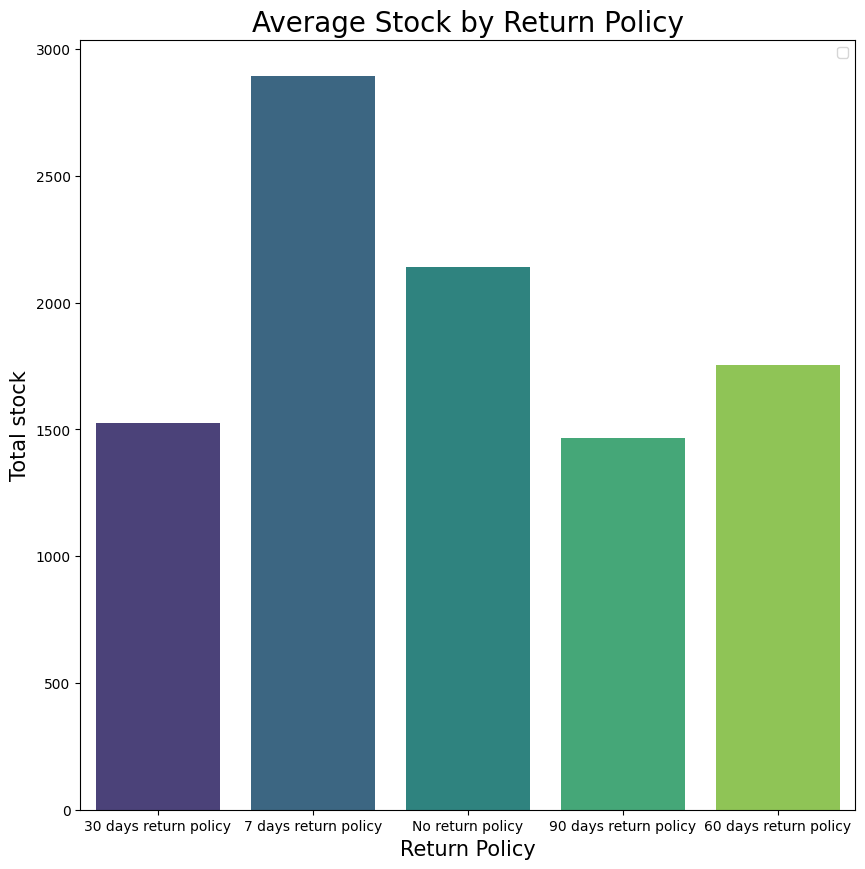

In [42]:
products_graph=create_bar_chart(
    dataframe=products_df,
    x_column="returnPolicy",
    y_column="stock",
    estimator="sum",
    chart_title="Average Stock by Return Policy",
    x_title="Return Policy",
    y_title="Total stock"
)

c:\Users\Dell\sales-data-analysis\services\functions.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart= sns.barplot(
c:\Users\Dell\sales-data-analysis\services\functions.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


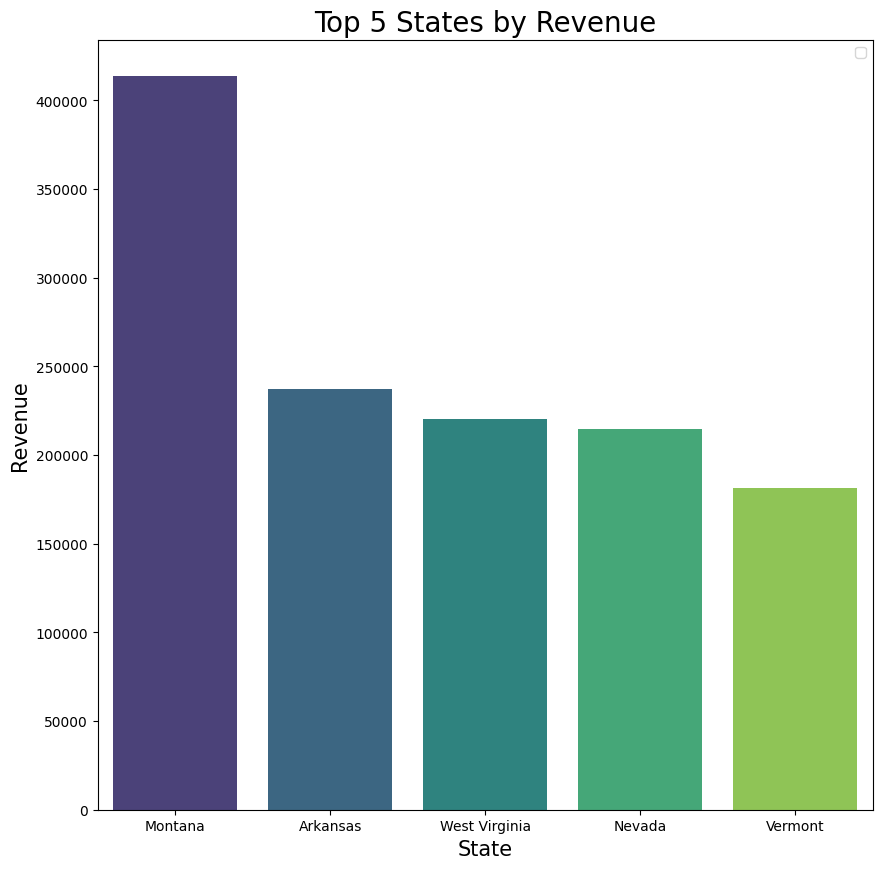

In [43]:
state_graph=create_bar_chart(group_state.head(5),
                             "address.stateCode",
                             "discountedTotal","sum",
                             "Top 5 States by Revenue",
                             "State",
                             "Revenue",
                             )

c:\Users\Dell\sales-data-analysis\services\functions.py:192: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatterplot=sns.scatterplot(


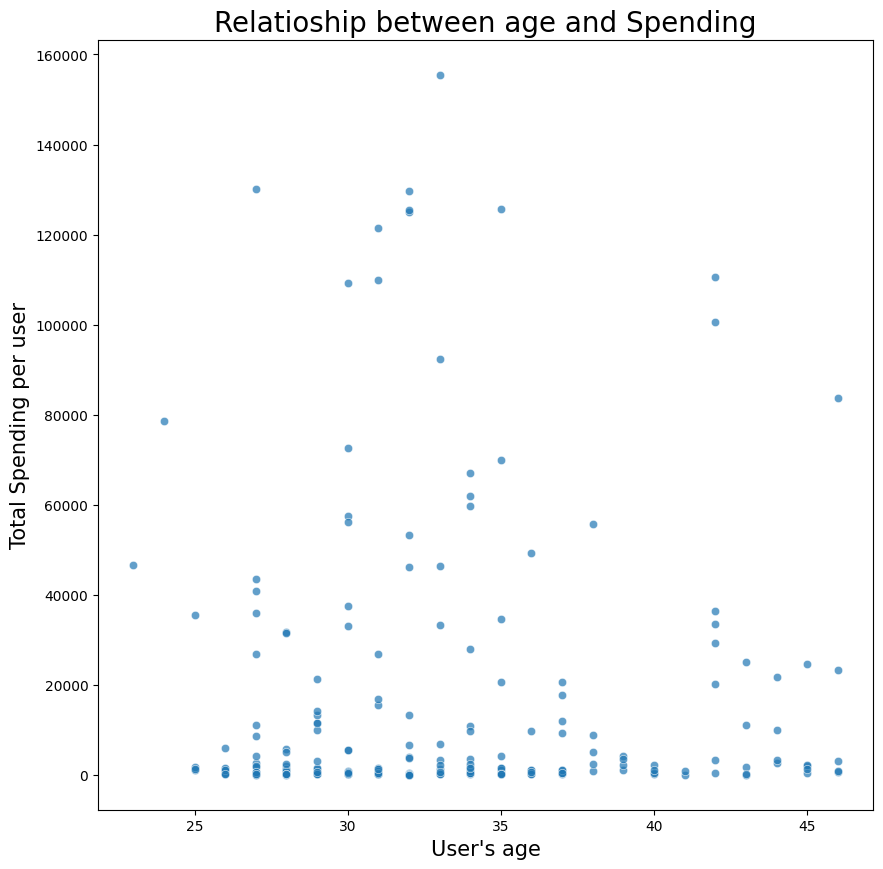

In [44]:
age_revenue_graph=create_scatterplot(
    group_user,
    "age",
    "discountedTotal",
    "Relatioship between age and Spending",
    "User's age",
    "Total Spending per user"
)

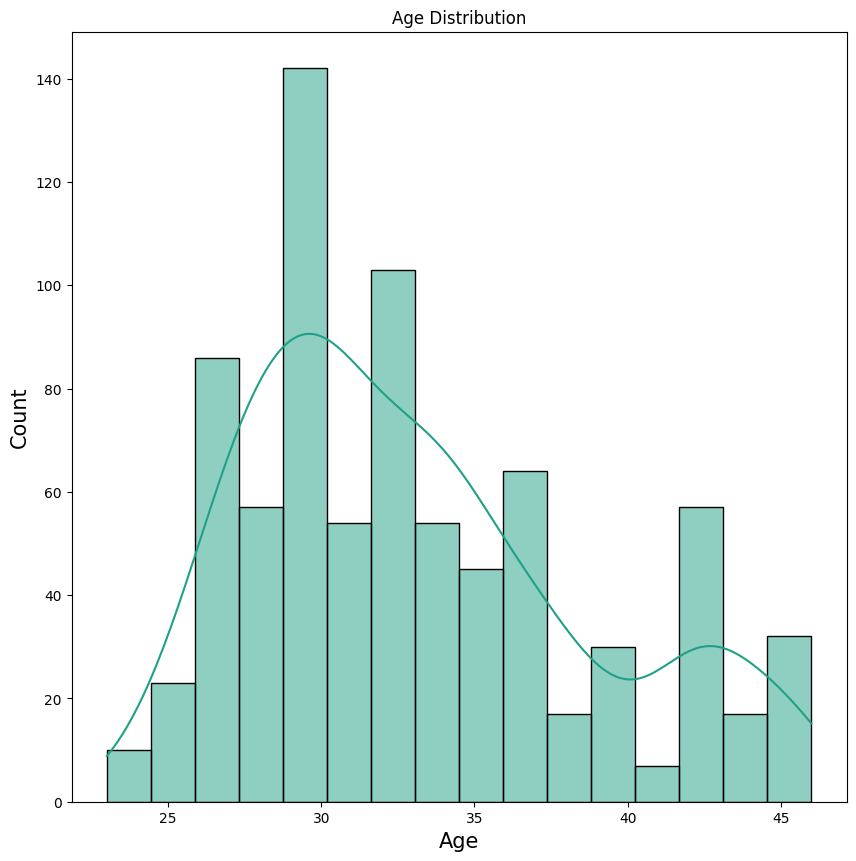

In [45]:
histogram=create_histogram(orders_merged,"age")

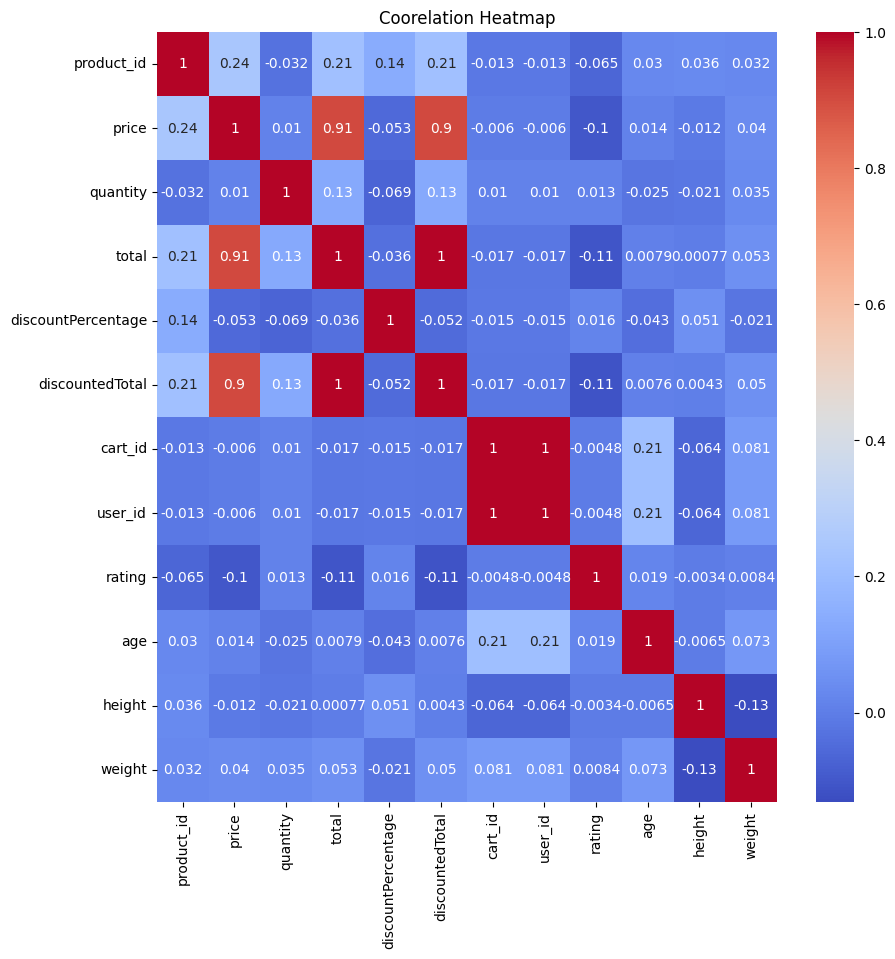

In [46]:
heatmap=create_heatmap(
    orders_merged,
    orders_merged.select_dtypes(include="number").columns
    )